<a href="https://colab.research.google.com/github/Bushraashraf786/heart-disease-risk-predictor/blob/main/heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# cell 1 - Libraries import
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib


In [ ]:
heart_df = pd.read_csv("/content/drive/MyDrive/heart_disease_combined.csv")
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# cell 3 - Missing values aur data types check karne ke liye
print("Missing Values:\n", heart_df.isnull().sum())
heart_df.info()


Missing Values:
 age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
source        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  target    920 non-null    int64  
 

In [ ]:
# cell 4
heart_df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.553261
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,0.497426
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [ ]:
#cell 5
heart_df['target'].value_counts()
heart_df.shape

(920, 15)

In [ ]:
# cell 6 - Sirf numeric columns select karein aur missing rows hatayein
numeric_df = heart_df.select_dtypes(include=[np.number])
clean_df = numeric_df.dropna()

X = clean_df.drop(columns='target', axis=1)
y = clean_df['target']

print("Clean features shape:", X.shape)

Clean features shape: (299, 13)


In [ ]:
# cell 7 - Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training Data Rows:", X_train.shape[0])
print("Testing Data Rows:", X_test.shape[0])

Training Data Rows: 239
Testing Data Rows: 60


In [ ]:
# cell 8 - Train the model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [ ]:
# cell 9 - Training accuracy
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(y_train, X_train_prediction)
print(f'Model Performance on Train Data: {training_data_accuracy * 100:.2f}%')

Model Performance on Train Data: 85.36%


In [ ]:
# cell 10 - Test accuracy
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(y_test, X_test_prediction)
print(f'Model Performance on Test Data: {test_data_accuracy * 100:.2f}%')
print(classification_report(y_test, X_test_prediction))

Model Performance on Test Data: 81.67%
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        32
           1       0.84      0.75      0.79        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60



In [ ]:
# cell 11 - Save the exact feature order the model was trained on (IMPORTANT for the web app)
feature_names = list(X_train.columns)
print("Model expects these features, in this order:", feature_names)

Model expects these features, in this order: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [ ]:
# cell 12 - Save model + feature list, then download to your computer
joblib.dump(model, 'heart_disease_model.pkl')
joblib.dump(feature_names, 'feature_names.pkl')
from google.colab import files
files.download('heart_disease_model.pkl')
files.download('feature_names.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# cell 13 - Libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_1451/3053767277.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=heart_df, palette=['#2ecc71', '#e74c3c'])


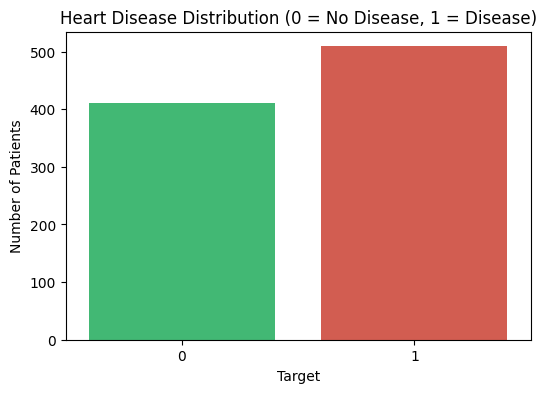

In [ ]:
# cell 14 - Target distribution (kitne patients ko disease hai vs nahi)
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=heart_df, palette=['#2ecc71', '#e74c3c'])
plt.title('Heart Disease Distribution (0 = No Disease, 1 = Disease)')
plt.xlabel('Target')
plt.ylabel('Number of Patients')
plt.show()

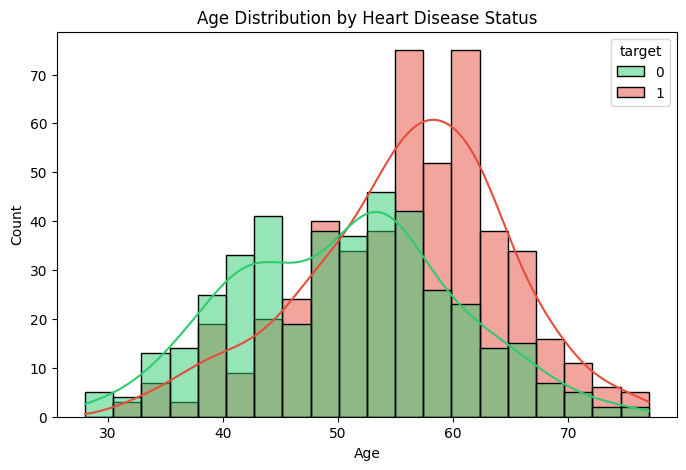

In [ ]:
# cell 15 - Age distribution by disease status
plt.figure(figsize=(8,5))
sns.histplot(data=heart_df, x='age', hue='target', kde=True, bins=20, palette=['#2ecc71', '#e74c3c'])
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

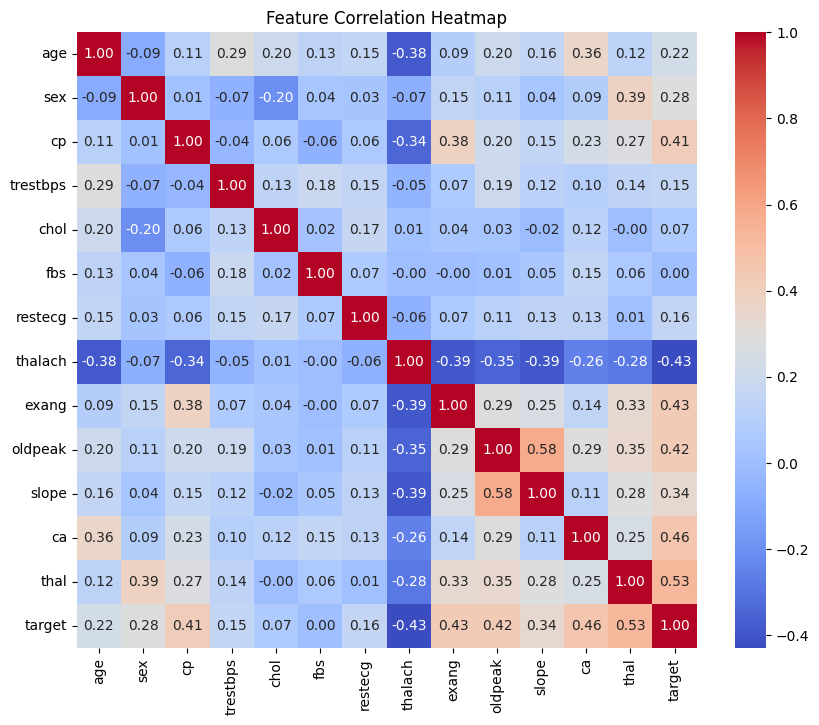

In [ ]:
# cell 16 - Correlation heatmap
plt.figure(figsize=(10,8))
corr = clean_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

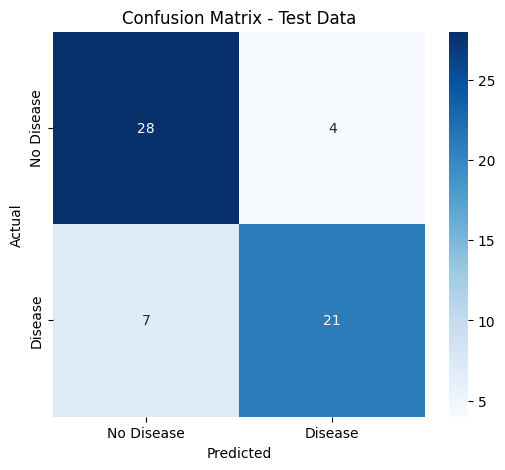

In [ ]:
# cell 17 - Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, X_test_prediction)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Test Data')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

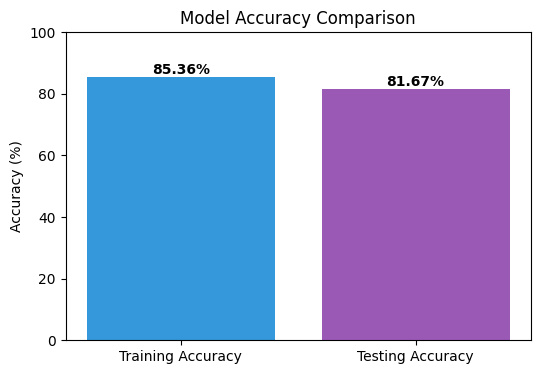

In [ ]:
# cell 18 - Train vs Test accuracy comparison
plt.figure(figsize=(6,4))
accuracies = [training_data_accuracy*100, test_data_accuracy*100]
plt.bar(['Training Accuracy', 'Testing Accuracy'], accuracies, color=['#3498db', '#9b59b6'])
plt.ylim(0, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v+1, f'{v:.2f}%', ha='center', fontweight='bold')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.show()

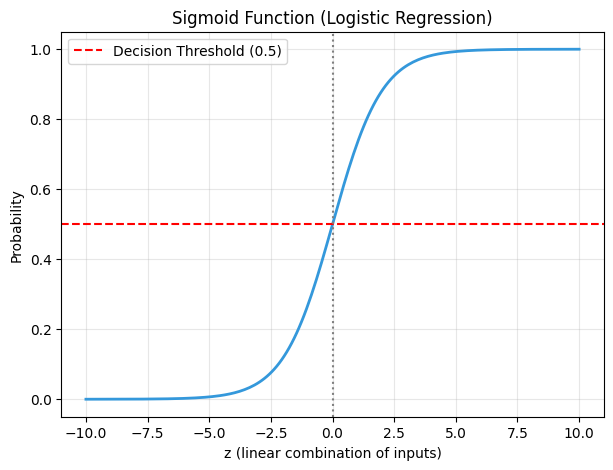

In [ ]:
# cell 19 - Sigmoid function (Logistic Regression ka core concept)
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(7,5))
plt.plot(z, sigmoid, color='#3498db', linewidth=2)
plt.axhline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.axvline(0, color='gray', linestyle=':')
plt.title('Sigmoid Function (Logistic Regression)')
plt.xlabel('z (linear combination of inputs)')
plt.ylabel('Probability')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

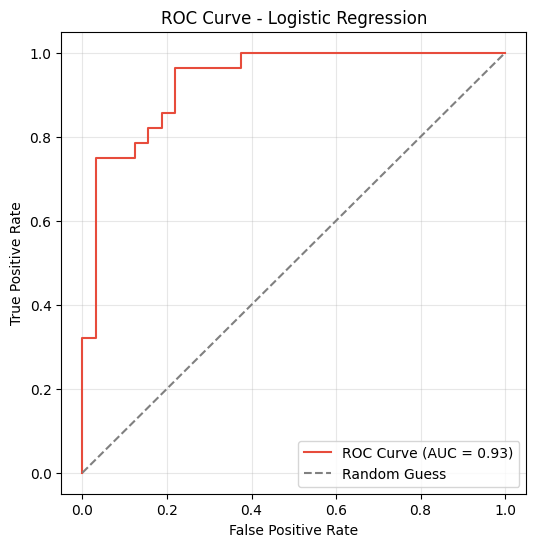

In [ ]:
# cell 20 - ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='#e74c3c', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

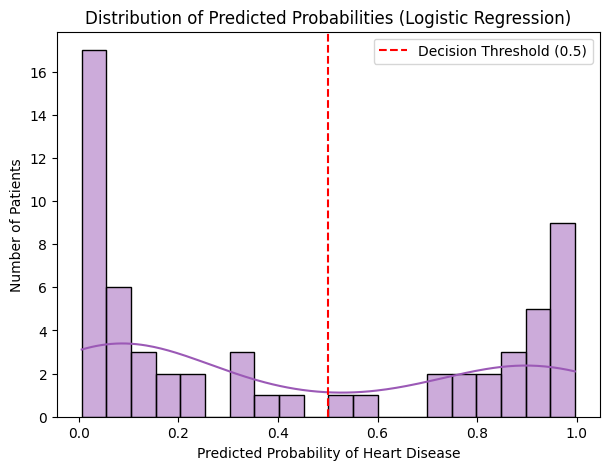

In [ ]:
# cell 21 - Predicted probabilities distribution
plt.figure(figsize=(7,5))
sns.histplot(y_proba, bins=20, kde=True, color='#9b59b6')
plt.axvline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.title('Distribution of Predicted Probabilities (Logistic Regression)')
plt.xlabel('Predicted Probability of Heart Disease')
plt.ylabel('Number of Patients')
plt.legend()
plt.show()

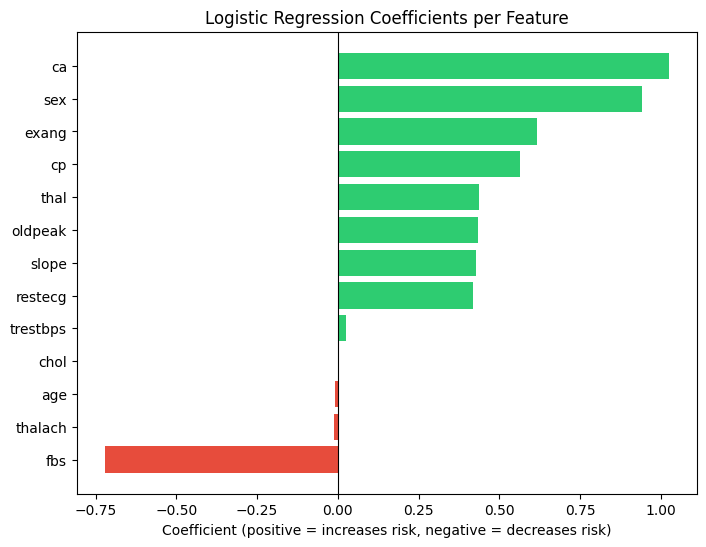

     Feature  Coefficient  Odds Ratio
5        fbs    -0.721016    0.486258
7    thalach    -0.011568    0.988499
0        age    -0.009015    0.991025
4       chol     0.004135    1.004144
3   trestbps     0.025552    1.025881
6    restecg     0.418340    1.519437
10     slope     0.426029    1.531164
9    oldpeak     0.432277    1.540762
12      thal     0.436027    1.546550
2         cp     0.562481    1.755021
8      exang     0.615726    1.851000
1        sex     0.940619    2.561565
11        ca     1.023181    2.782029


In [ ]:
# cell 22 - Logistic Regression coefficients (odds ratio ke sath)
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values('Coefficient')

plt.figure(figsize=(8,6))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.title('Logistic Regression Coefficients per Feature')
plt.xlabel('Coefficient (positive = increases risk, negative = decreases risk)')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

print(coef_df)